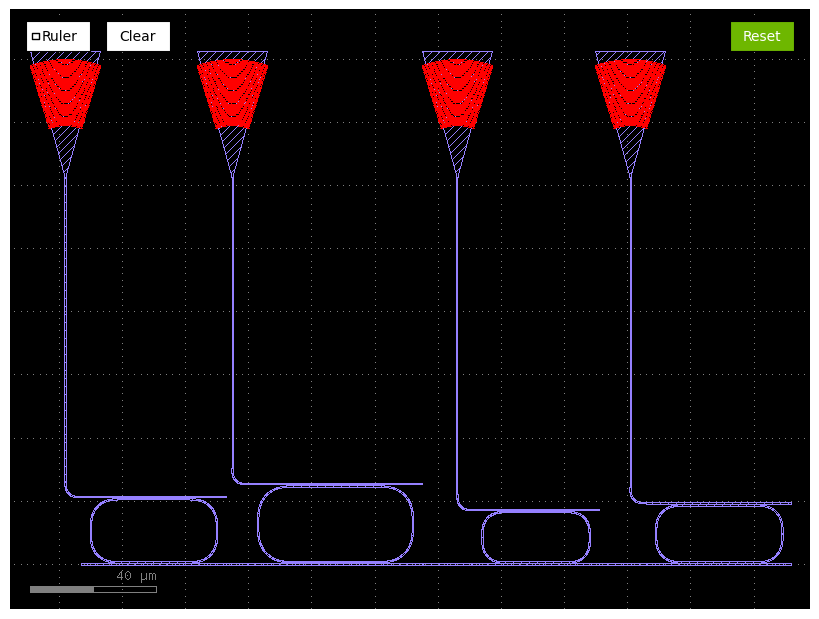

In [1]:
import gdsfactory as gf
from gdsfactory.typings import ComponentSpec
from typing import Dict, Optional
import cspdk.si220.cband

cspdk.si220.cband.activate_pdk()
pdk = gf.get_active_pdk()


def multi_ring_array(
    n_rings: int = 4,
    cell: ComponentSpec = "ring_double",
    cell_settings: Optional[Dict[int, Dict]] = None,
    spacing_x: float = 100.0,
    add_gratings: bool = False,
    alternate_mirror: bool = False,
    gratings_distance: float = 100.0,
) -> gf.Component:
    """
    Array of add‑drop (double‑bus) rings with optional drop‑port gratings.
    All gratings are aligned to the same Y coordinate.

    Parameters
    ----------
    n_rings : int
        How many ring resonators to place.
    cell : ComponentSpec
        Ring cell (default “ring_double” from CSPDK).
    cell_settings : dict[int, dict]
        Per‑ring override of the ring’s parameters  
        (e.g. {0: {"radius": 10}, 1: {"radius": 12}, …}).
    spacing_x : float
        Horizontal pitch between rings.
    add_gratings : bool
        If true, an elliptical grating coupler is connected to each port “o3”.
    alternate_mirror : bool
        Mirror every second ring in Y to compact the footprint.
    gratings_distance : float
        Vertical offset between a ring’s drop port and its grating (µm).
    """
    c = gf.Component()
    rings = []

    # ------------------------------------------------------------------ #
    # 1.  Place rings, all aligned to a common reference Y (bus height)  #
    # ------------------------------------------------------------------ #
    cell_settings = cell_settings or {}
    # Reference ring = the one with the largest radius (gives tallest port stack)
    ref_settings = max(
        (cell_settings.get(i, {}) for i in range(n_rings)),
        key=lambda d: d.get("radius", 10),
    )
    ref_ring = cell(**ref_settings) if callable(cell) else pdk.get_component(cell, **ref_settings)
    ref_y = ref_ring.ports["o1"].center[1]

    for i in range(n_rings):
        settings = cell_settings.get(i, {})
        ring_inst = cell(**settings) if callable(cell) else pdk.get_component(cell, **settings)
        ring = c << ring_inst

        # Vertical alignment (bus ports “o1/o2” share the reference Y)
        y_offset = ref_y - ring.ports["o1"].center[1]
        ring.movey(y_offset)

        # Optional mirroring (before shifting in X to preserve handedness)
        if alternate_mirror and i % 2:
            ring.mirror_y()

        # Horizontal placement
        ring.movex(i * spacing_x)
        rings.append(ring)

        # Chain the through‑bus (o2 → o1) between successive rings
        if i > 0:
            gf.routing.route_single(
                c,
                port1=rings[i - 1].ports["o2"],
                port2=ring.ports["o1"],
                bend="bend_euler",
                cross_section="strip",
            )

    # ------------------------------------------------------------------ #
    # 2.  Add perfectly Y‑aligned gratings (optional)                    #
    # ------------------------------------------------------------------ #
    if add_gratings:
        # One global Y coordinate for every grating
        g_y = rings[0].ports["o3"].center[1] + gratings_distance
        for i, ring in enumerate(rings, start=0):
            if "o3" in ring.ports:
                gr = c << pdk.get_component("grating_coupler_elliptical")
                gr.name = f"grating_{i}"
                gr.rotate(90)
                # keep X local to each ring, force Y to the shared g_y
                gr.move((ring.ports["o3"].x - 5, g_y))
                gf.routing.route_single(
                    c,
                    port1=ring.ports["o3"],
                    port2=gr.ports["o1"],
                    bend="bend_euler",
                    cross_section="strip",
                )

    # ------------------------------------------------------------------ #
    # 3.  External bus ports                                             #
    # ------------------------------------------------------------------ #
    c.add_port("bus_in",  port=rings[0].ports["o1"])
    c.add_port("bus_out", port=rings[-1].ports["o2"])
    return c


# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    ring_settings = {
        0: {"radius": 10, "gap": 0.20, "length_x": 20},
        1: {"radius": 12, "gap": 0.25, "length_x": 25},
        2: {"radius":  8, "gap": 0.15, "length_x": 18},
        3: {"radius":  9, "gap": 0.20, "length_x": 22},
    }

    c_param = multi_ring_array(
        n_rings=4,
        cell="ring_double",
        cell_settings=ring_settings,
        spacing_x=60,
        add_gratings=True,
        alternate_mirror=False,
        gratings_distance=100,
    )

    from axiomatic.pic_helpers import plot_circuit
    plot_circuit(c_param)